## Explaining the Model and its Learning from the Features

In [18]:
#Importing the requiered libraries
import joblib
import pandas as pd
import shap

In [19]:
#Loading the model
model = joblib.load('best_model.pkl')
X_test = pd.read_csv('X_test.csv')

In [20]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

### Explaining the model with the help of visuals

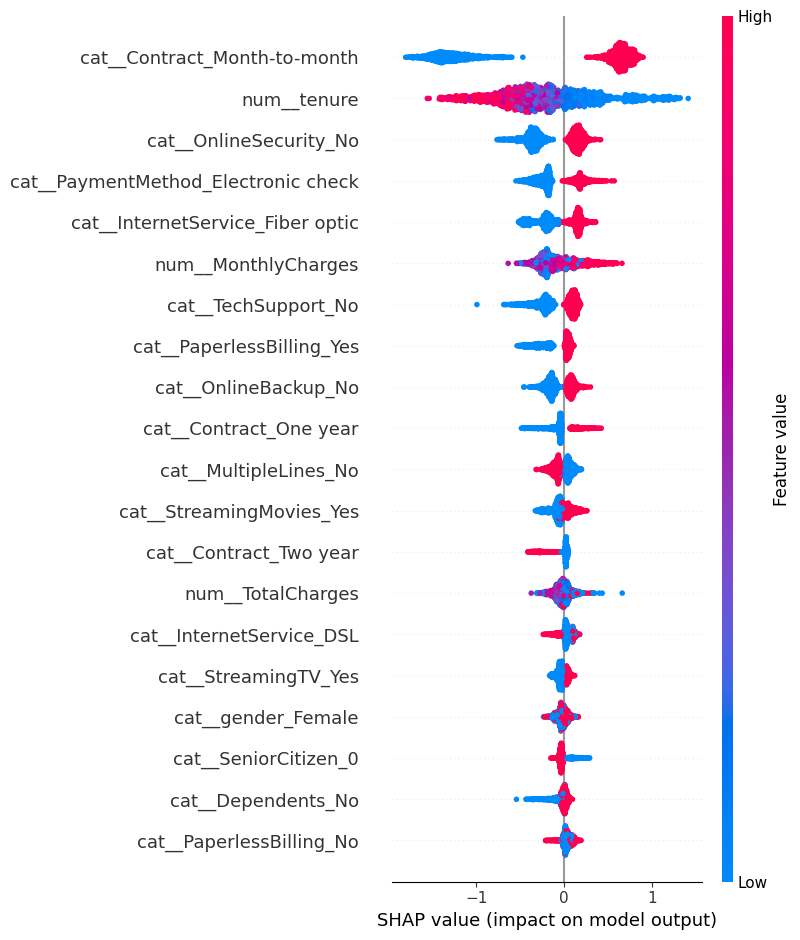

In [21]:
shap.summary_plot(shap_values,X_test,feature_names= X_test.columns.tolist())

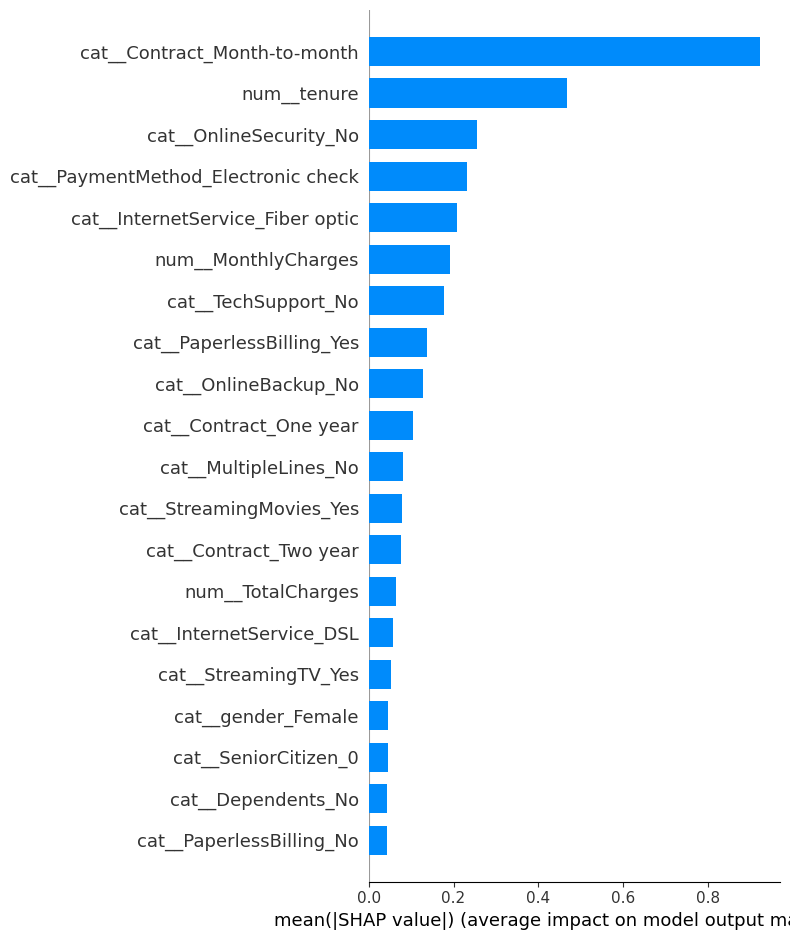

In [22]:
shap.summary_plot(shap_values,X_test,feature_names= X_test.columns.tolist(), plot_type="bar")

#### These graphs tell us that 'Contract_Month-to-month' and 'Tenure' are the  biggest drivers to predict churns

In [ ]:
##Force Plot for a single customer
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])

##### This plot shows the for the customer with given feature the models output is -3.12 so model thinks it wont churn

Background dataset has 1761 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1761 when initializing the masker.


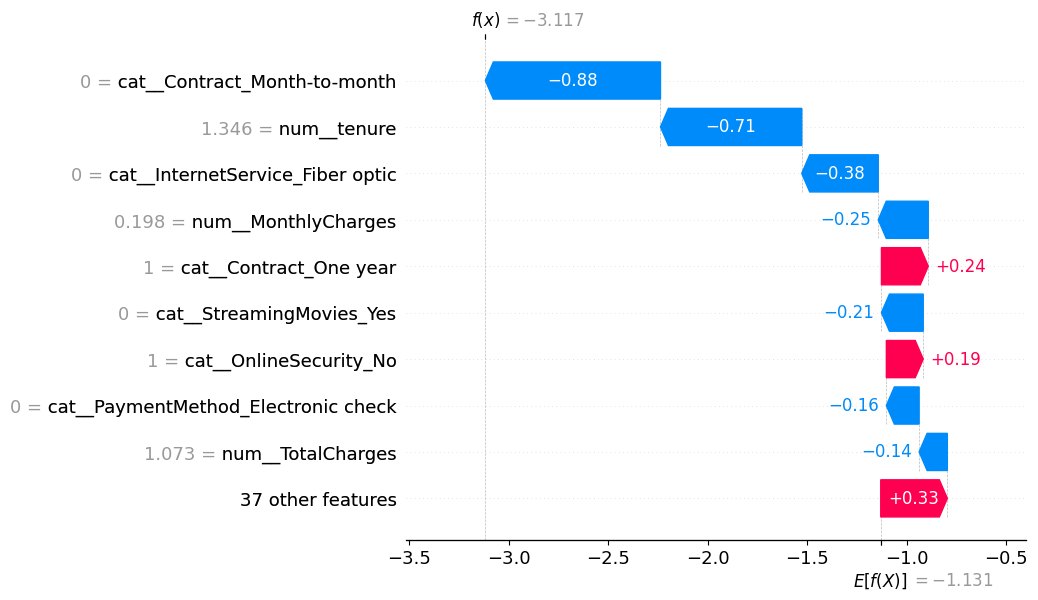

In [28]:
#Making a waterfall plot
explainer2 = shap.Explainer(model, X_test)
shap_values2 = explainer2(X_test)
shap.plots.waterfall(shap_values2[0])

### In this way we are able to explain the dependence of model's output on the given features